# Analisis Exploratorio de Hongos: Comestibles vs Venenosos

Este proyecto analiza un dataset de **8,124 hongos** con 23 caracteristicas morfologicas para identificar patrones que distinguen a los hongos comestibles de los venenosos. El objetivo es determinar cuales atributos fisicos son los mejores indicadores de toxicidad.

**Relevancia practica:** La identificacion correcta de hongos venenosos es critica para la seguridad alimentaria. Este analisis puede informar guias de identificacion y servir como base para modelos de clasificacion.

**Dataset:** [UCI Mushroom Dataset](https://archive.ics.uci.edu/ml/datasets/mushroom) - 8,124 muestras, 23 variables categoricas.

## 1. Importacion y Exploracion Inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

# Cargar datos
df = pd.read_csv('mushroom_data.csv')

# Convertir Bruises a string para evitar problemas con boolean
df['Bruises'] = df['Bruises'].astype(str)

print(f"Dataset: {df.shape[0]} hongos, {df.shape[1]} caracteristicas")
print(f"\nClases:")
for cls, count in df['Class'].value_counts().items():
    pct = count / len(df) * 100
    print(f"  {cls}: {count} ({pct:.1f}%)")

print(f"\nPrimeras 5 muestras:")
df.head()

Dataset: 8124 hongos, 23 caracteristicas

Clases:
  Edible: 4208 (51.8%)
  Poisonous: 3916 (48.2%)

Primeras 5 muestras:


,Class,Cap Shape,Cap Surface,Cap Color,Bruises,Odor,Gill Attachment,Gill Spacing,Gill Size,Gill Color,...,Stalk Surface Below Ring,Stalk Color Above Ring,Stalk Color Below Ring,Veil Type,Veil Color,Ring Number,Ring Type,Spore Print Color,Population,Habitat
0,Poisonous,Convex,Smooth,Brown,True,Pungent,Free,Close,Narrow,Black,...,Smooth,White,White,Partial,White,One,Pendant,Black,Scattered,Urban
1,Edible,Convex,Smooth,Yellow,True,Almond,Free,Close,Broad,Black,...,Smooth,White,White,Partial,White,One,Pendant,Brown,Numerous,Grasses
2,Edible,Bell,Smooth,White,True,Anise,Free,Close,Broad,Brown,...,Smooth,White,White,Partial,White,One,Pendant,Brown,Numerous,Meadows
3,Poisonous,Convex,Scaly,White,True,Pungent,Free,Close,Narrow,Brown,...,Smooth,White,White,Partial,White,One,Pendant,Black,Scattered,Urban
4,Edible,Convex,Smooth,Gray,False,NaN,Free,Crowded,Broad,Black,...,Smooth,White,White,Partial,White,One,Evanescent,Brown,Abundant,Grasses


In [2]:
# Resumen general de todas las variables
print("=" * 60)
print("RESUMEN DE VARIABLES")
print("=" * 60)
for col in df.columns:
    n_unique = df[col].nunique()
    most_common = df[col].mode()[0]
    most_common_pct = (df[col] == most_common).mean() * 100
    print(f"  {col:<28} {n_unique:>2} valores | Moda: {most_common} ({most_common_pct:.0f}%)")

RESUMEN DE VARIABLES
  Class                         2 valores | Moda: Edible (52%)
  Cap Shape                     6 valores | Moda: Convex (45%)
  Cap Surface                   4 valores | Moda: Scaly (40%)
  Cap Color                    10 valores | Moda: Brown (28%)
  Bruises                       2 valores | Moda: False (58%)
  Odor                          8 valores | Moda: Foul (27%)
  Gill Attachment               2 valores | Moda: Free (97%)
  Gill Spacing                  2 valores | Moda: Close (84%)
  Gill Size                     2 valores | Moda: Broad (69%)
  Gill Color                   12 valores | Moda: Buff (21%)
  Stalk Shape                   2 valores | Moda: Tapering (57%)
  Stalk Root                    5 valores | Moda: Bulbous (46%)
  Stalk Surface Above Ring      4 valores | Moda: Smooth (64%)
  Stalk Surface Below Ring      4 valores | Moda: Smooth (61%)
  Stalk Color Above Ring        9 valores | Moda: White (55%)
  Stalk Color Below Ring        9 valores |

## 2. Distribucion de Variables

Visualizamos la distribucion de cada variable categorica. Las variables con alta cardinalidad se muestran como barplots, mientras que las de baja cardinalidad se representan como pie charts para mayor claridad.

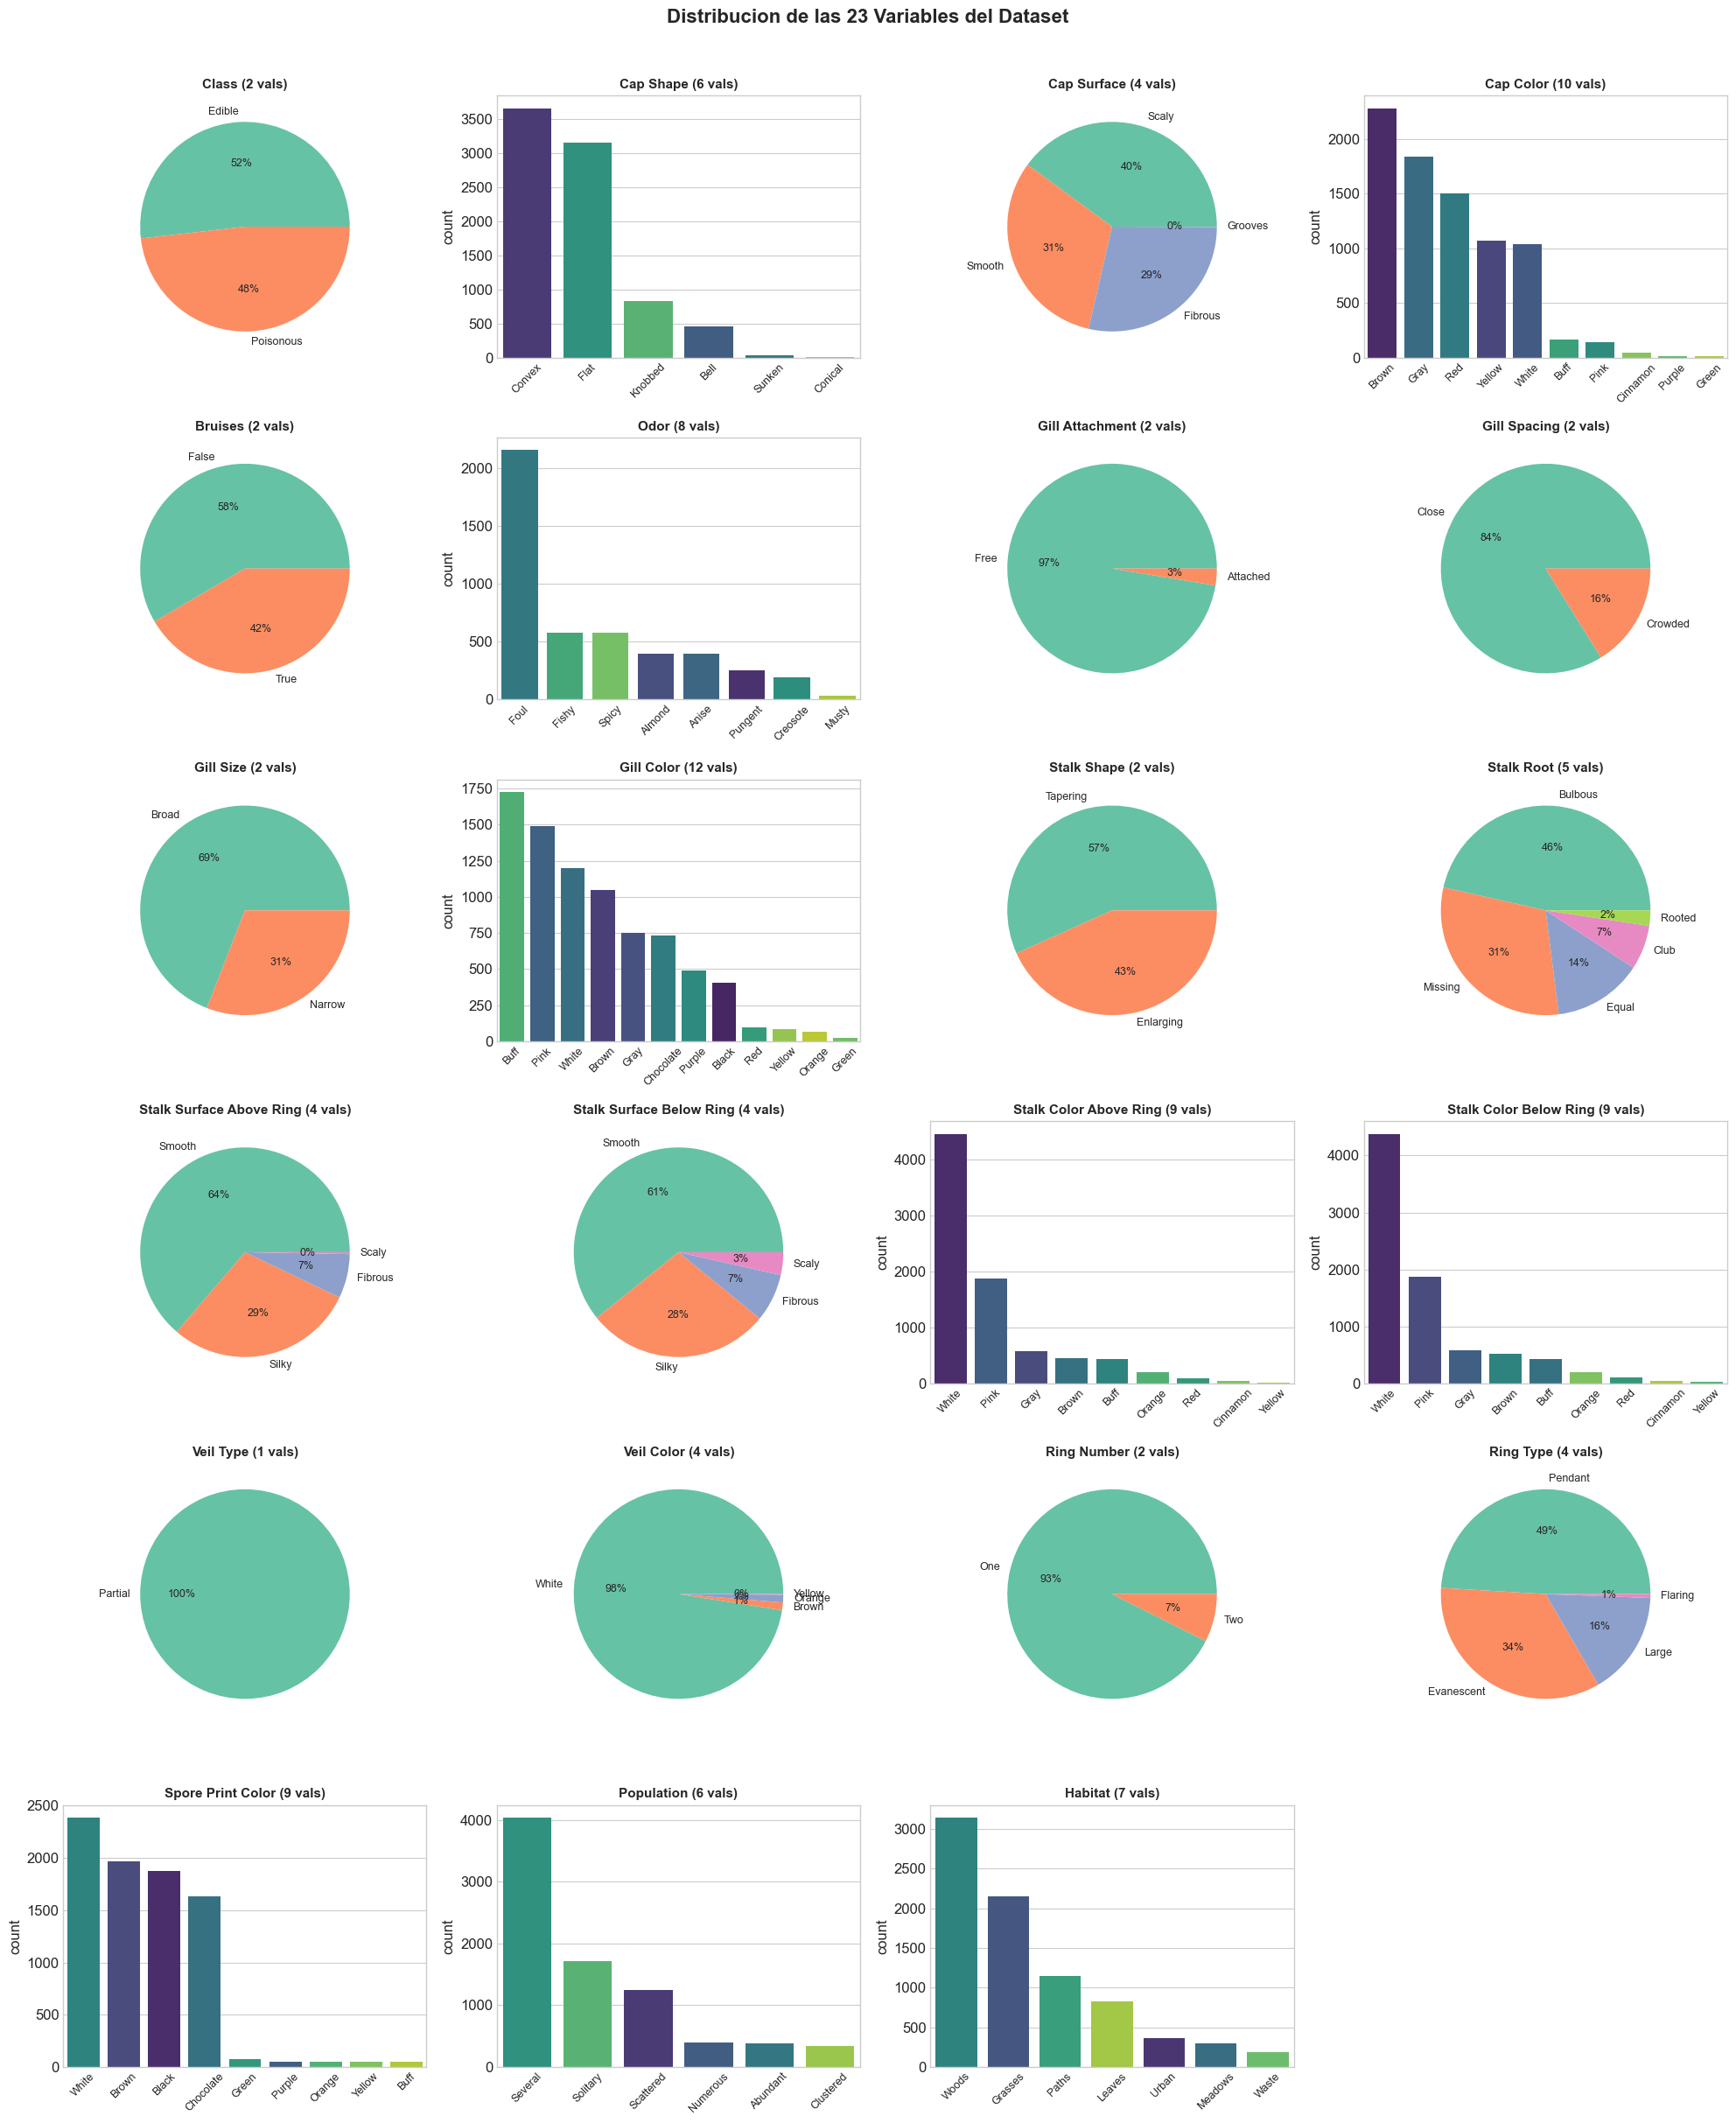

In [3]:
# Visualizacion automatica de todas las variables
columns = df.columns.tolist()
n_cols = 4
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(columns):
    n_unique = df[col].nunique()
    value_counts = df[col].value_counts()
    
    if n_unique <= 5:
        # Pie chart para pocas categorias
        axes[i].pie(value_counts.values, labels=value_counts.index, autopct='%1.0f%%',
                    colors=sns.color_palette('Set2', n_unique), textprops={'fontsize': 9})
    else:
        # Barplot para muchas categorias
        sns.countplot(x=df[col], data=df, order=value_counts.index, ax=axes[i],
                     palette='viridis', hue=df[col], legend=False)
        axes[i].tick_params(axis='x', rotation=45, labelsize=9)
    
    axes[i].set_title(f'{col} ({n_unique} vals)', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

# Ocultar ejes vacios
for j in range(len(columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribucion de las 23 Variables del Dataset', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Analisis Clave: Comestibles vs Venenosos

Esta es la pregunta central: que caracteristicas distinguen a los hongos venenosos de los comestibles? Analizamos las variables mas relevantes comparando ambas clases.

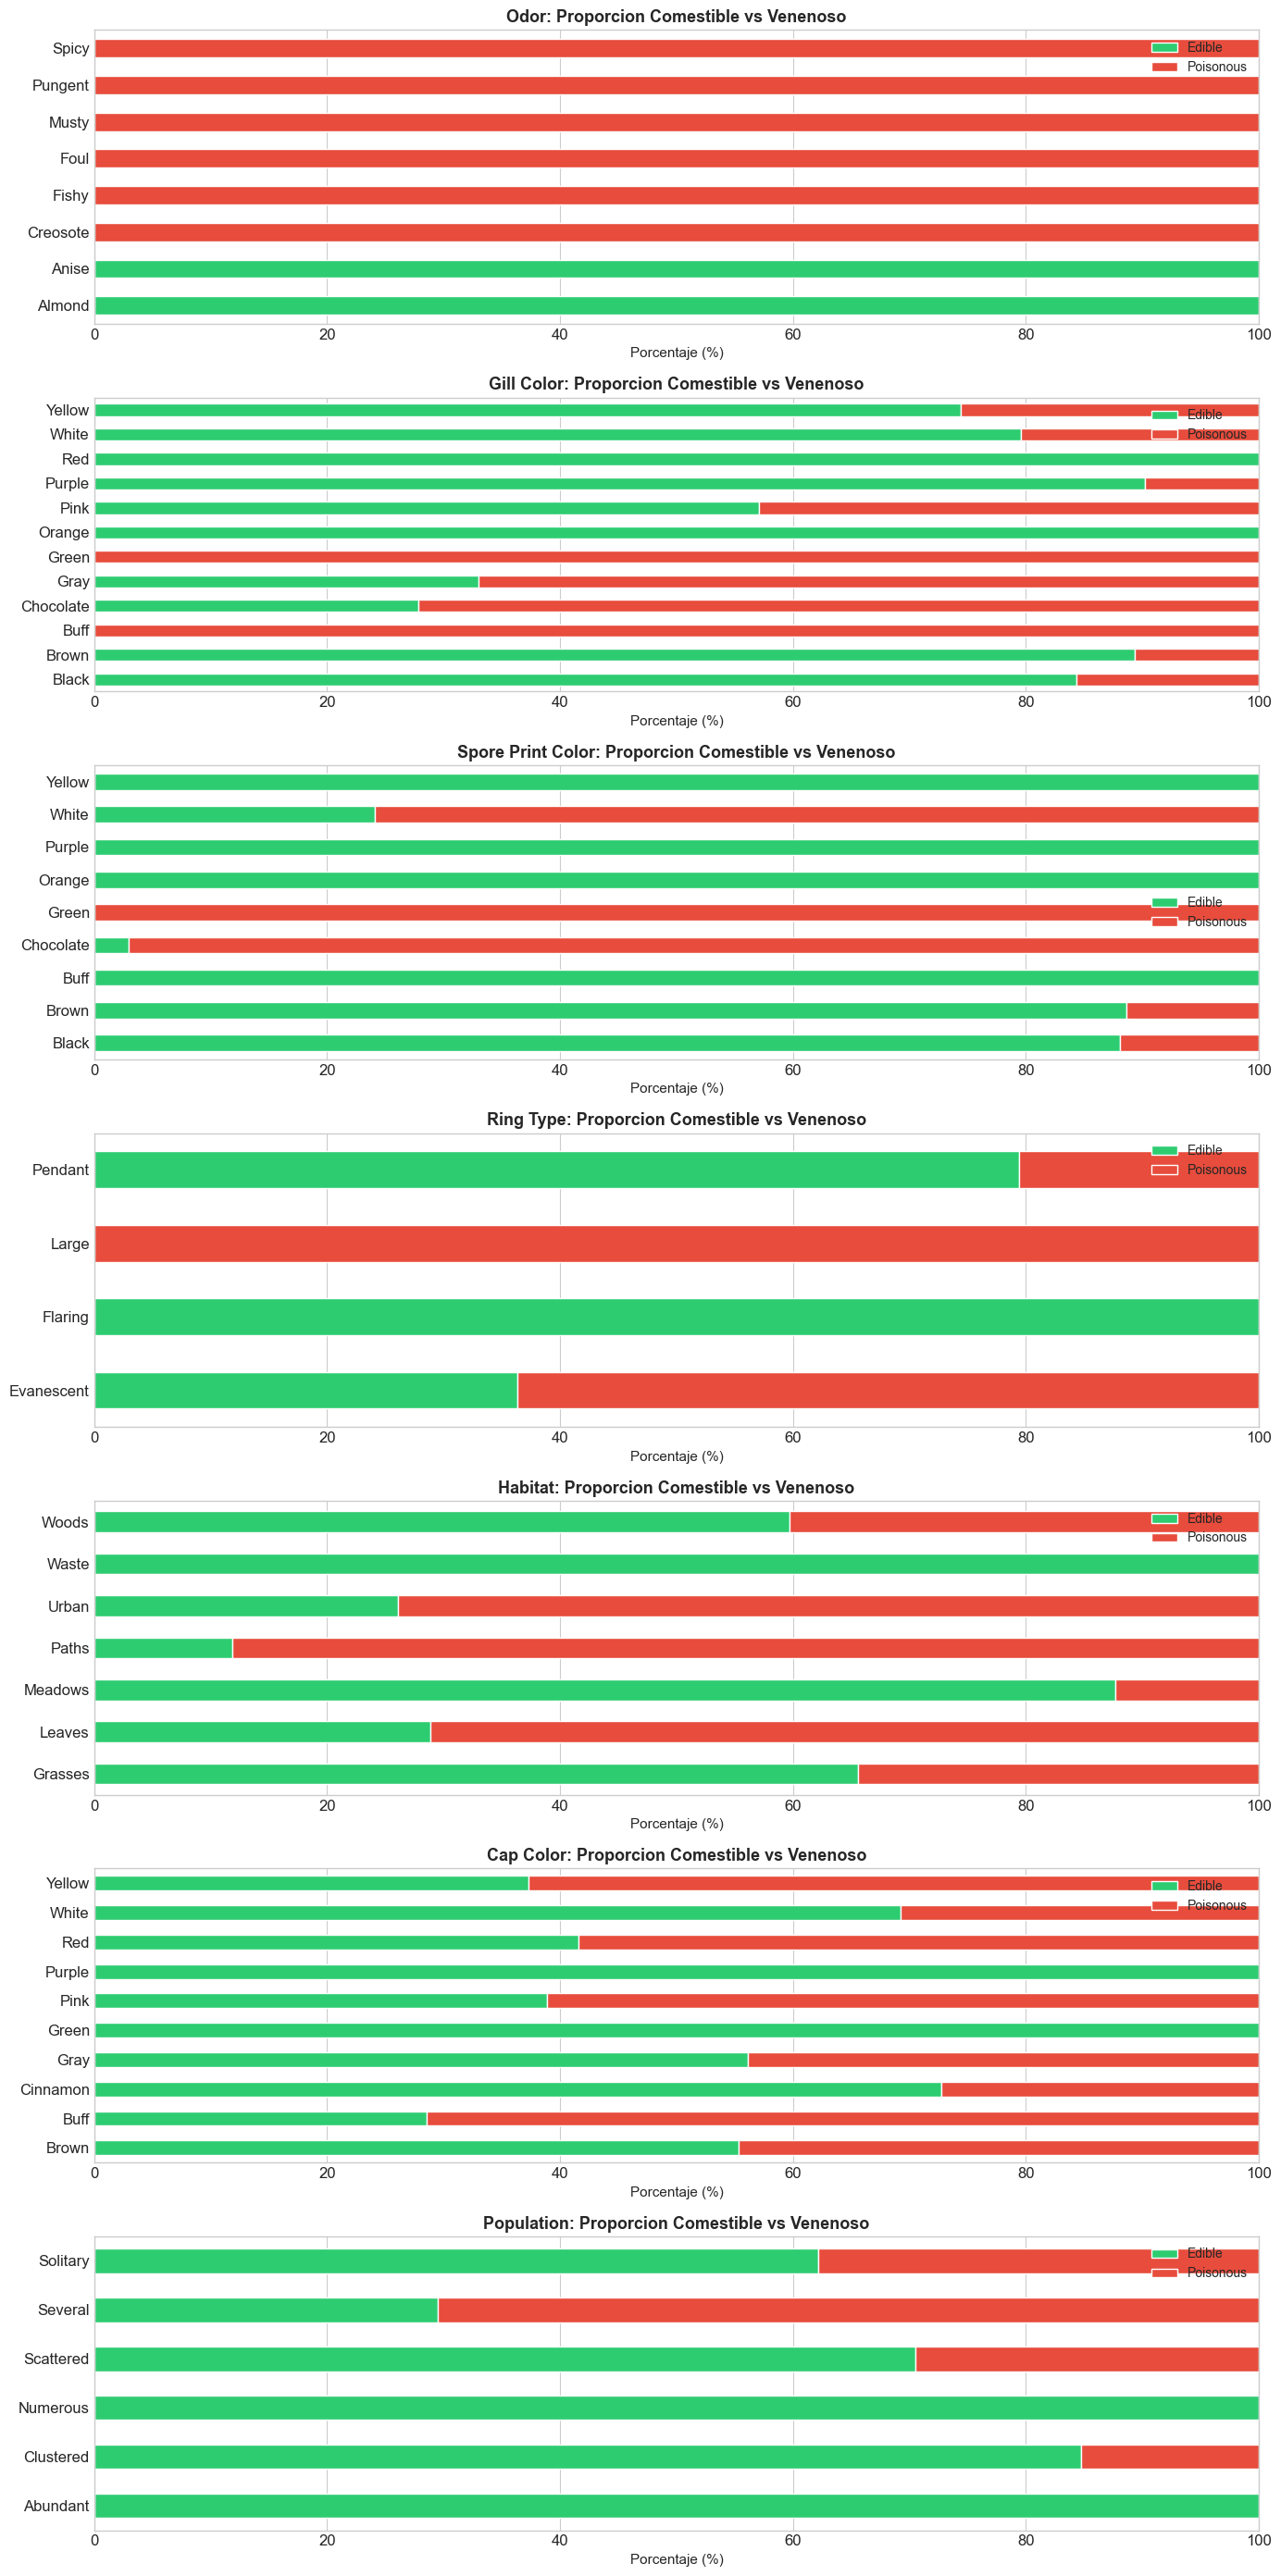

In [4]:
# Variables mas discriminantes
key_vars = ['Odor', 'Gill Color', 'Spore Print Color', 'Ring Type', 'Habitat', 'Cap Color', 'Population']

fig, axes = plt.subplots(len(key_vars), 1, figsize=(14, len(key_vars) * 4))

for i, var in enumerate(key_vars):
    ct = pd.crosstab(df[var], df['Class'], normalize='index') * 100
    ct.plot(kind='barh', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'], edgecolor='white')
    axes[i].set_title(f'{var}: Proporcion Comestible vs Venenoso', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Porcentaje (%)', fontsize=11)
    axes[i].set_ylabel('')
    axes[i].legend(['Edible', 'Poisonous'], fontsize=10)
    axes[i].set_xlim(0, 100)

plt.tight_layout()
plt.show()

In [5]:
# Resumen: que variables predicen mejor la toxicidad?
print("=" * 65)
print("INDICADORES CLAVE DE TOXICIDAD")
print("=" * 65)

for var in key_vars:
    ct = pd.crosstab(df[var], df['Class'])
    # Encontrar valores 100% venenosos o 100% comestibles
    for val in ct.index:
        total = ct.loc[val].sum()
        if total > 50:  # solo valores con suficientes muestras
            pois_pct = ct.loc[val, 'Poisonous'] / total * 100 if 'Poisonous' in ct.columns else 0
            if pois_pct > 95:
                print(f"  {var} = {val}: {pois_pct:.0f}% venenoso (n={total})")
            elif pois_pct < 5:
                print(f"  {var} = {val}: {100-pois_pct:.0f}% comestible (n={total})")

INDICADORES CLAVE DE TOXICIDAD
  Odor = Almond: 100% comestible (n=400)
  Odor = Anise: 100% comestible (n=400)
  Odor = Creosote: 100% venenoso (n=192)
  Odor = Fishy: 100% venenoso (n=576)
  Odor = Foul: 100% venenoso (n=2160)
  Odor = Pungent: 100% venenoso (n=256)
  Odor = Spicy: 100% venenoso (n=576)
  Gill Color = Buff: 100% venenoso (n=1728)
  Gill Color = Orange: 100% comestible (n=64)
  Gill Color = Red: 100% comestible (n=96)
  Spore Print Color = Chocolate: 97% venenoso (n=1632)
  Spore Print Color = Green: 100% venenoso (n=72)
  Ring Type = Large: 100% venenoso (n=1296)
  Habitat = Waste: 100% comestible (n=192)


  Population = Abundant: 100% comestible (n=384)
  Population = Numerous: 100% comestible (n=400)


## 4. Matriz de Asociacion entre Variables Clave

Evaluamos la fuerza de asociacion entre las variables categoricas y la clase (comestible/venenoso) usando el coeficiente V de Cramer.

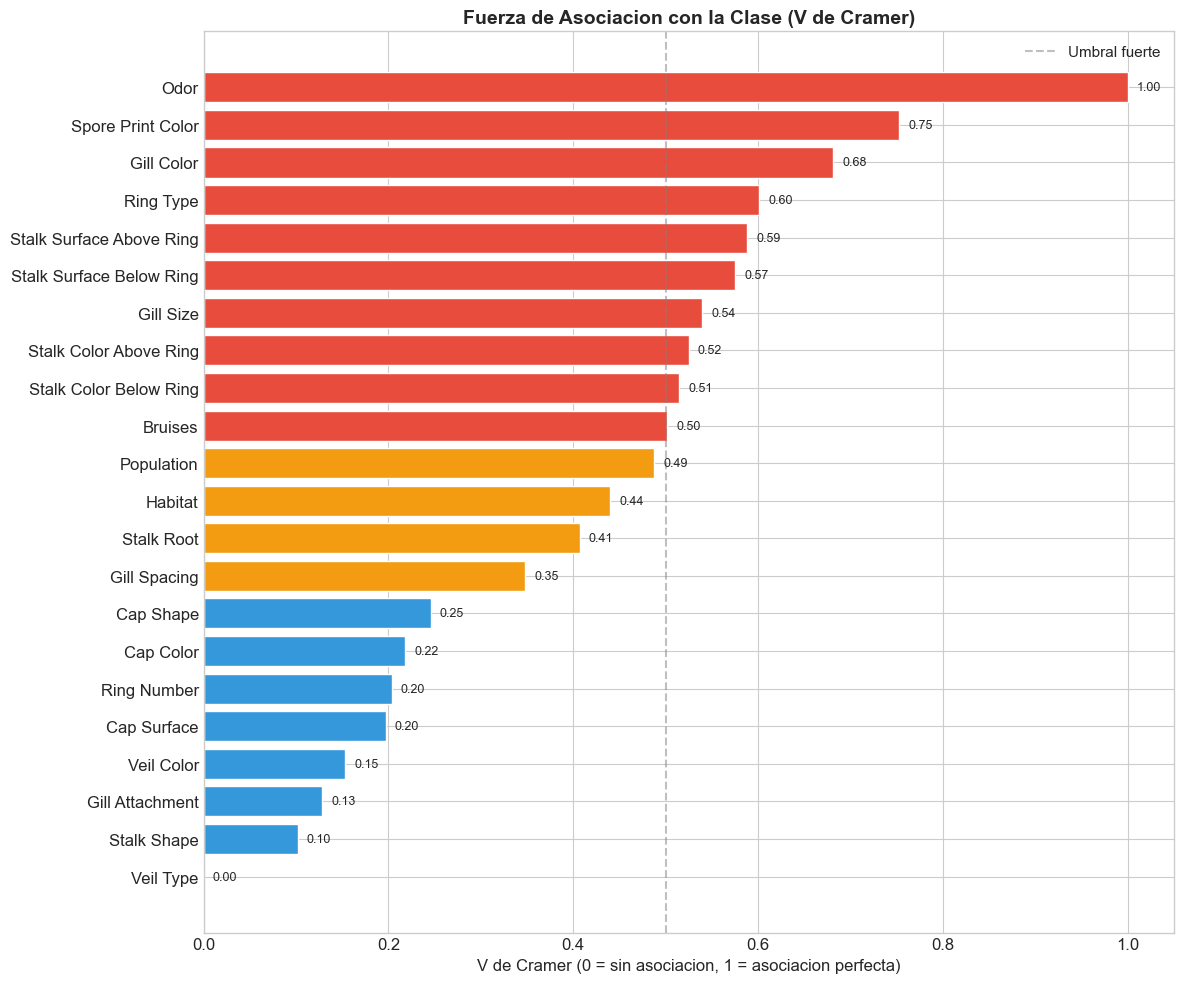

Las variables con V de Cramer > 0.5 son los predictores mas fuertes de toxicidad.


In [6]:
# V de Cramer para medir asociacion entre cada variable y la clase
from scipy.stats import chi2_contingency

cramer_scores = {}
for col in df.columns:
    if col != 'Class':
        contingency = pd.crosstab(df[col], df['Class'])
        chi2, p, dof, expected = chi2_contingency(contingency)
        n = contingency.sum().sum()
        min_dim = min(contingency.shape) - 1
        cramer_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
        cramer_scores[col] = cramer_v

# Ordenar y visualizar
cramer_df = pd.DataFrame.from_dict(cramer_scores, orient='index', columns=["Cramer's V"])
cramer_df = cramer_df.sort_values("Cramer's V", ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
colors = ['#e74c3c' if v > 0.5 else '#f39c12' if v > 0.3 else '#3498db' for v in cramer_df["Cramer's V"]]
bars = ax.barh(cramer_df.index, cramer_df["Cramer's V"], color=colors, edgecolor='white')
ax.set_title("Fuerza de Asociacion con la Clase (V de Cramer)", fontsize=14, fontweight='bold')
ax.set_xlabel("V de Cramer (0 = sin asociacion, 1 = asociacion perfecta)", fontsize=12)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Umbral fuerte')
ax.legend(fontsize=11)

for bar, val in zip(bars, cramer_df["Cramer's V"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Las variables con V de Cramer > 0.5 son los predictores mas fuertes de toxicidad.")

## 5. Conclusiones

### Reglas de identificacion descubiertas

1. **Olor (Odor)** es el predictor mas fuerte. Los hongos con olor a "Pungent", "Creosote" o "Foul" son practicamente siempre venenosos. Los hongos sin olor ("None") o con olor a "Anise" son comestibles.

2. **Gill Color** y **Spore Print Color** son indicadores significativos. Colores "Buff" en las agallas y esporas "Chocolate" o "Green" se asocian fuertemente con toxicidad.

3. **Veil Type** tiene un solo valor para todo el dataset, por lo que no aporta informacion discriminante.

### Implicaciones practicas

- Una regla simple basada unicamente en el **olor** podria clasificar correctamente la gran mayoria de hongos.
- Para un modelo de ML, las variables con V de Cramer > 0.5 serian las features mas valiosas.
- Las variables de baja asociacion (como Cap Shape o Cap Surface) podrian descartarse para simplificar el modelo sin perder precision significativa.

### Proximos pasos sugeridos
- Implementar un modelo de clasificacion (Decision Tree, Random Forest) usando las top features identificadas.
- Evaluar si un arbol de decision simple basado en Odor + Gill Color logra accuracy > 95%.

---
*Analisis exploratorio del UCI Mushroom Dataset, 8,124 muestras, 23 variables categoricas.*